In [701]:
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import math
from pathlib import Path

from xarch_tokenizers.logging.report_utils import (
    load_predictions,
    load_all_samples,
    clean_model_name,
)
from xarch_tokenizers.logging.plot_utils import (
    setup_styles,
    get_new_6_fig,
    MODEL_TO_COLOR,
    get_new_fig,
)


setup_styles()
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [702]:


def get_canonical_and_perturbed_df(
    samples,
    only_keep_canonical_true: bool = False,
    keep_remains_or_becomes_correct: bool = False,
    only_keep_perturbed_true: bool = False,
):
    """returns filtered out samples too"""
    if (
        (only_keep_canonical_true and keep_remains_or_becomes_correct)
        or (only_keep_canonical_true and only_keep_perturbed_true)
        or (keep_remains_or_becomes_correct and only_keep_perturbed_true)
    ):
        raise ValueError(
            f"Please pass these exclusively, only_keep_canonical_true: true for canonical, model_name true, keep_remains_or_becomes_correct: True to include the ones where the perturbed version becomes correct"
        )
    print(f"Processing {len(samples)} examples")
    canonical_samples = samples[samples["is_canonical"]]
    perturbed_samples = samples[~samples["is_canonical"]]
    canonical_values = canonical_samples[["set_id", "model_name", METRIC]].rename(
        columns={METRIC: f"canonical_{METRIC}"}
    )

    perturbed_samples = perturbed_samples.merge(
        canonical_values, on=["set_id", "model_name"], how="left"
    )
    perturbed_samples[f"canonical-perturbed_{METRIC}"] = (
        perturbed_samples[f"canonical_{METRIC}"] - perturbed_samples[METRIC]
    )

    if only_keep_canonical_true:
        print(
            f"Cleaning samples, will be dropping entries (set_id-model pairs) where the canonical is predicted wrong."
        )
        correct_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ]
        print(
            f"Keeping {len(correct_canonical_pairs)} correct pairs, dropping {len(canonical_samples) - len(correct_canonical_pairs)} entries."
        )

        canonical_samples = canonical_samples[canonical_samples[METRIC] == 1]

        # Step 3: Filter perturbed_samples to keep only rows with correct canonical pairs
        # Method 1: Using merge (RECOMMENDED)
        perturbed_samples = perturbed_samples.merge(
            correct_canonical_pairs,
            on=["set_id", "model_name"],
            how="inner",  # Only keep rows that exist in both
        )
        samples = pd.concat((canonical_samples, perturbed_samples), ignore_index=True)

    if keep_remains_or_becomes_correct:
        # Get pairs where perturbed samples are correct (becomes or remains correct)
        correct_perturbed_pairs = perturbed_samples[perturbed_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ].drop_duplicates()

        # Get pairs where canonical samples are correct (remains correct)
        correct_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ]

        # Combine: pairs that either remain correct OR become correct
        remains_or_becomes_correct = pd.concat(
            [correct_canonical_pairs, correct_perturbed_pairs]
        ).drop_duplicates()

        # Filter both datasets to only include these pairs
        canonical_samples = canonical_samples.merge(
            remains_or_becomes_correct, on=["set_id", "model_name"], how="inner"
        )

        perturbed_samples = perturbed_samples.merge(
            remains_or_becomes_correct, on=["set_id", "model_name"], how="inner"
        )
        samples = pd.concat((canonical_samples, perturbed_samples), ignore_index=True)
        print(f"After filtering:{len(samples)}")
    if only_keep_perturbed_true:
        # Get pairs where perturbed samples are correct (becomes or remains correct)
        correct_perturbed_pairs = perturbed_samples[perturbed_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ].drop_duplicates()

        # Get pairs where canonical samples are correct (remains correct)
        wrong_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 0][
            ["set_id", "model_name"]
        ]
        # Find cases where canonical wrong AND perturbed correct (recovery cases)
        becomes_correct = pd.merge(
            wrong_canonical_pairs,
            correct_perturbed_pairs,
            how="inner",
            on=["set_id", "model_name"], 
        )
        print(becomes_correct)

        # Filter both datasets to only include recovery cases
        canonical_samples = canonical_samples.merge(
            becomes_correct, on=["set_id", "model_name"], how="inner"
        )
        print(canonical_samples[METRIC].sum())

        perturbed_samples = perturbed_samples.merge(
            becomes_correct, on=["set_id", "model_name"], how="inner"
        )

        samples = pd.concat([canonical_samples, perturbed_samples], ignore_index=True)
        print(f"After filtering: {len(samples)}")

    return samples, canonical_samples, perturbed_samples

In [703]:
samples.head()

,doc_id,target,resps,metrics,acc,acc_norm,model_name,tokenizer_name,task,question,...,token_counts.gpt2,token_counts.meta-llama/Llama-3.2-1B,token_counts.microsoft/Phi-3-mini-4k-instruct,token_counts.mistralai/tekken,token_counts.tiktoken/gpt-4o,token_counts.tokenmonster/englishcode-32000-consistent-v1,task_pretty_name,vocab_bucket,is_canonical,var_id
14666,0,0,"[[[-3.84375, False]], [[-6.0625, False]], [[-1...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_cannon...,Dr Smith is a doctor. Occupation of Dr Smith is,...,12,11,13,11,12,11,Canonical,Large,True,0.0
14280,0,1,"[[[-7.65625, False]], [[-4.28125, False]], [[-...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_simila...,Dr Smith is a doctor. Occupation of Dr Smith is,...,12,11,13,11,12,11,Similar words,Large,False,1.0
14580,0,1,"[[[-39.0, False]], [[-25.25, False]], [[-24.87...","[acc, acc_norm]",0,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_homogl...,Dr Smith is a doctor. Occupation of Dr Smith is,...,12,11,13,11,12,11,Homoglyphs,Large,False,1.0
14864,0,0,"[[[-5.25, False]], [[-6.53125, False]], [[-8.5...","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_capita...,DR SMITH IS A DOCTOR. OCCUPATION OF DR SMITH IS,...,18,16,18,17,16,16,Capitalization,Large,False,11.0
14760,0,0,"[[[-3.921875, False]], [[-5.75, False]], [[-9....","[acc, acc_norm]",1,1,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_english_contra...,Dr Smith's a doctor. Occupation of Dr Smith is,...,12,11,14,11,12,12,Contractions,Large,False,12.0


## Farsi Subset

In [704]:
METRIC = "acc_norm"
OUTPUT_DIR_ = Path("./output/prelim-results-v3")

suffix = "(Still correct)"
only_keep_canonical_true = True
keep_remains_or_becomes_correct = False
only_keep_perturbed_true = False

# suffix = "(Remains or Becomes Correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = True
# only_keep_perturbed_true = False

# suffix = "(Flipped to correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = False
# only_keep_perturbed_true = True

suffix = "(All)" 
only_keep_canonical_true = False
keep_remains_or_becomes_correct = False
only_keep_perturbed_true = False

base_dir = Path("../results/paper").resolve().absolute()
base_dir = Path("../results/paper-v2").resolve().absolute()
code_pattern = "*farsi_tokenizer*"
title_pattern = "Farsi - "
OUTPUT_DIR = OUTPUT_DIR_/"farsi"

code_pattern = "*tokenizer_robustness_completion_turkish*"
title_pattern = "Turkish - "
OUTPUT_DIR = OUTPUT_DIR_/"turkish"

code_pattern = "*tokenizer_robustness_completion_stem*"
title_pattern = "STEM - "
OUTPUT_DIR = OUTPUT_DIR_/"stem"

# code_pattern = "*tokenizer_robustness_completion_math*"
# title_pattern = "MATH - "
# OUTPUT_DIR = OUTPUT_DIR_/"math"

# code_pattern = "*tokenizer_robustness_completion_english*"
# title_pattern = "English - "
# OUTPUT_DIR = OUTPUT_DIR_/"english"

# code_pattern = "*tokenizer_robustness_completion_chinese*"
# title_pattern = "Chinese - "
# OUTPUT_DIR = OUTPUT_DIR_/"chinese"

# code_pattern = "*tokenizer_robustness_completion_italian*"
# title_pattern = "Italian - "
# OUTPUT_DIR = OUTPUT_DIR_/"italian"

SUFFIX = suffix.lower().replace("(","").replace(")","")
OUTPUT_DIR = OUTPUT_DIR/SUFFIX
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
base_dir = Path("../results/paper-v3").resolve().absolute()
base_dir.exists()
pred_files = list([p for p in base_dir.rglob(f"samples{code_pattern}.jsonl")])
len(pred_files), pred_files[:5]


(308,
 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_stem_script_2025-09-16T00-57-08.561580.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_stem_combining_diacritics_2025-09-16T00-57-08.561580.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_stem_latex_2025-09-16T00-57-08.561580.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_stem_double_struck_2025-09-16T00-57-08.561580.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robu

In [705]:

task_counts = all_samples.groupby("task")["model_name"].value_counts().groupby(level=0).mean()
valid_tasks = task_counts[task_counts>=5].index
(task_counts>=5).index
valid_tasks
# task_counts

Index(['tokenizer_robustness_completion_english_abbreviations',
       'tokenizer_robustness_completion_english_borrowing',
       'tokenizer_robustness_completion_english_cannonical',
       'tokenizer_robustness_completion_english_capitalization',
       'tokenizer_robustness_completion_english_character_deletion',
       'tokenizer_robustness_completion_english_character_substitution',
       'tokenizer_robustness_completion_english_colloquial',
       'tokenizer_robustness_completion_english_combining_diacritics',
       'tokenizer_robustness_completion_english_compounds',
       'tokenizer_robustness_completion_english_contractions',
       'tokenizer_robustness_completion_english_date_formats',
       'tokenizer_robustness_completion_english_deliberate_misspellings',
       'tokenizer_robustness_completion_english_emoji_substitution',
       'tokenizer_robustness_completion_english_grammatical_errors',
       'tokenizer_robustness_completion_english_historical_spelling',
       '

In [706]:
all_samples = load_all_samples(
    base_dir,
    patterns=[code_pattern],
    flatten_doc=True,
    match_date=False,
    simplify_df=True,
)

task_counts = all_samples.groupby("task")["model_name"].value_counts().groupby(level=0).mean()
valid_tasks = task_counts[task_counts>=5].index
all_samples = all_samples[all_samples["task"].isin(valid_tasks)]
all_samples["is_canonical"] = (
    all_samples["variation_id"].apply(lambda x: str(x).split(".")[1]) == "0"
)
all_samples = all_samples[all_samples["subcategories"] != "Turkish, Numerical formats"]
all_samples = all_samples[all_samples["task"] != "tokenizer_robustness_completion_english_space_additions"]
valid_tasks = all_samples.pivot_table(index=["model_name", "task"], values=METRIC, aggfunc="count")
all_samples = all_samples
samples, canonical_df, perturbed_df = get_canonical_and_perturbed_df(
    all_samples,
    only_keep_canonical_true=only_keep_canonical_true,
    keep_remains_or_becomes_correct=keep_remains_or_becomes_correct,
    only_keep_perturbed_true=only_keep_perturbed_true,
)

samples.head()
samples["subcategories"].value_counts()
all_samples["set_id"].value_counts()

308 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_stem_script_2025-09-16T00-57-08.561580.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_stem_combining_diacritics_2025-09-16T00-57-08.561580.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_stem_latex_2025-09-16T00-57-08.561580.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_stem_double_struck_2025-09-16T00-57-08.561580.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_comp

set_id
670    392
674    350
671    350
644    350
673    336
694    336
604    322
643    322
642    308
693    308
640    308
690    294
672    294
683    238
680    224
668    210
666    196
665    196
664    196
663    196
662    182
681    168
667    168
684    168
623    154
660    154
607    140
682    140
691    126
621    112
645    112
646     98
692     98
609     98
627     98
625     98
669     84
648     84
661     84
647     84
630     84
626     84
606     84
605     84
602     70
603     70
601     70
624     56
631     42
629     42
628     42
633     28
632     28
675     28
Name: count, dtype: int64

In [707]:
pv = all_samples.pivot_table(index=["model_name", "is_canonical"], values=METRIC)
pv.to_csv(OUTPUT_DIR/f"model_canonical_{METRIC}.csv")
pv

acc_norm
model_name   is_canonical          
Aya          False         0.514184
             True          0.717949
BLOOM        False         0.533688
             True          0.756410
ByT5         False         0.556738
             True          0.769231
Comma        False         0.570922
             True          0.794872
GPT-2        False         0.572695
             True          0.807692
GPT-4o       False         0.558511
             True          0.833333
Gemma-2      False         0.542553
             True          0.807692
Llama-3.2    False         0.547872
             True          0.833333
Phi-3        False         0.565603
             True          0.794872
Qwen-3       False         0.549645
             True          0.743590
Tekken       False         0.546099
             True          0.807692
TokenMonster False         0.484043
             True          0.705128
XGLM         False         0.620567
             True          0.769231
mBERT        False         0.517730
             True          0.794872

              acc_norm
vocab_bucket          
Large         0.580997
Medium        0.571262
Small         0.575935
X-Small       0.582555


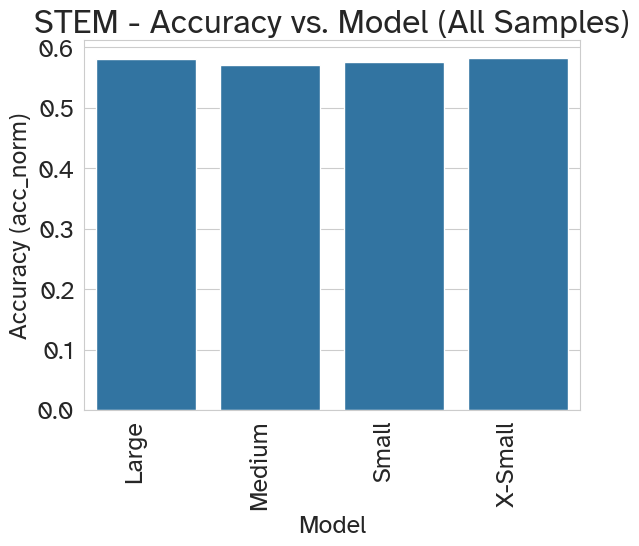

In [708]:
### Here using ALL SAMPLES

XAXIS = "model_name"
XAXIS = "vocab_bucket"
accuracies_by_model = all_samples.pivot_table(
    index=XAXIS, values=METRIC, aggfunc="mean"
)
sns.barplot(accuracies_by_model, x=XAXIS, y=METRIC)
# sns.barplot(accuracies_by_model, x=XAXIS, y=METRIC, palette=MODEL_TO_COLOR)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy ({METRIC})")
plt.title(f"{title_pattern}Accuracy vs. Model (All Samples)")
plt.savefig(OUTPUT_DIR/f"all_samples_{METRIC}.pdf", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

In [709]:
samples["vocab_bucket"]

8487     Large
8488     Large
8855     Large
8673     Large
8624     Large
         ...  
6525    Medium
6677    Medium
6664    Medium
6473    Medium
6625    Medium
Name: vocab_bucket, Length: 8988, dtype: object

### Canonical vs. Pertuerbed

                           acc_norm
model_name   is_canonical          
Aya          False         0.514184
             True          0.717949
BLOOM        False         0.533688
             True          0.756410
ByT5         False         0.556738
             True          0.769231
Comma        False         0.570922
             True          0.794872
GPT-2        False         0.572695
             True          0.807692
GPT-4o       False         0.558511
             True          0.833333
Gemma-2      False         0.542553
             True          0.807692
Llama-3.2    False         0.547872
             True          0.833333
Phi-3        False         0.565603
             True          0.794872
Qwen-3       False         0.549645
             True          0.743590
Tekken       False         0.546099
             True          0.807692
TokenMonster False         0.484043
             True          0.705128
XGLM         False         0.620567
             True          0

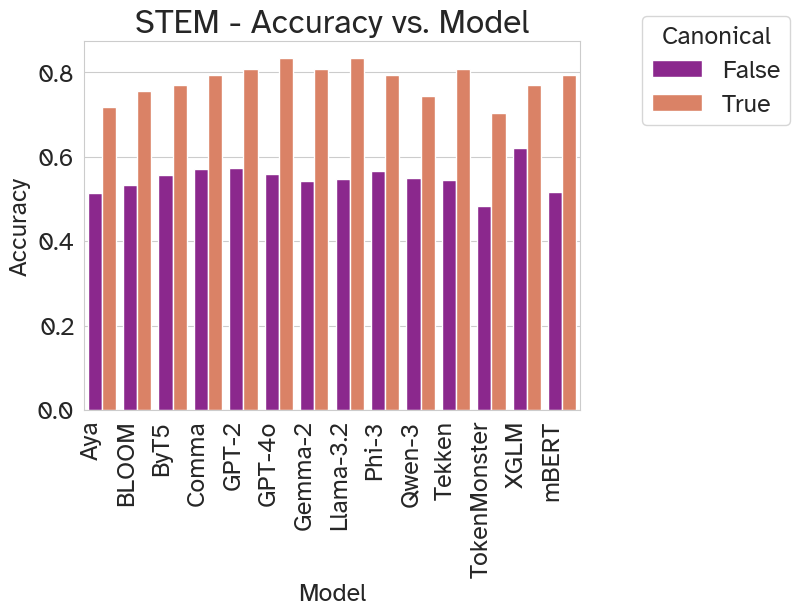

In [710]:
accuracies_by_model = all_samples.pivot_table(
    index=["model_name", "is_canonical"], values=METRIC, aggfunc="mean"
)
# sns.barplot(accuracies_by_model, x="is_canonical", y=METRIC, hue="model_name", palette=MODEL_TO_COLOR)
# xlabel = "Canonical"
sns.barplot(accuracies_by_model, x="model_name", y=METRIC, hue="is_canonical", palette="plasma")
xlabel = "Model"
plt.xticks(rotation=90, ha="right")
plt.xlabel(xlabel)
plt.ylabel("Accuracy")
plt.title(f"{title_pattern}Accuracy vs. Model")
plt.legend(bbox_to_anchor=(1.1, 1.1), title="Canonical")
plt.savefig(OUTPUT_DIR/f"canonical_vs_perturbed_{METRIC}.pdf", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

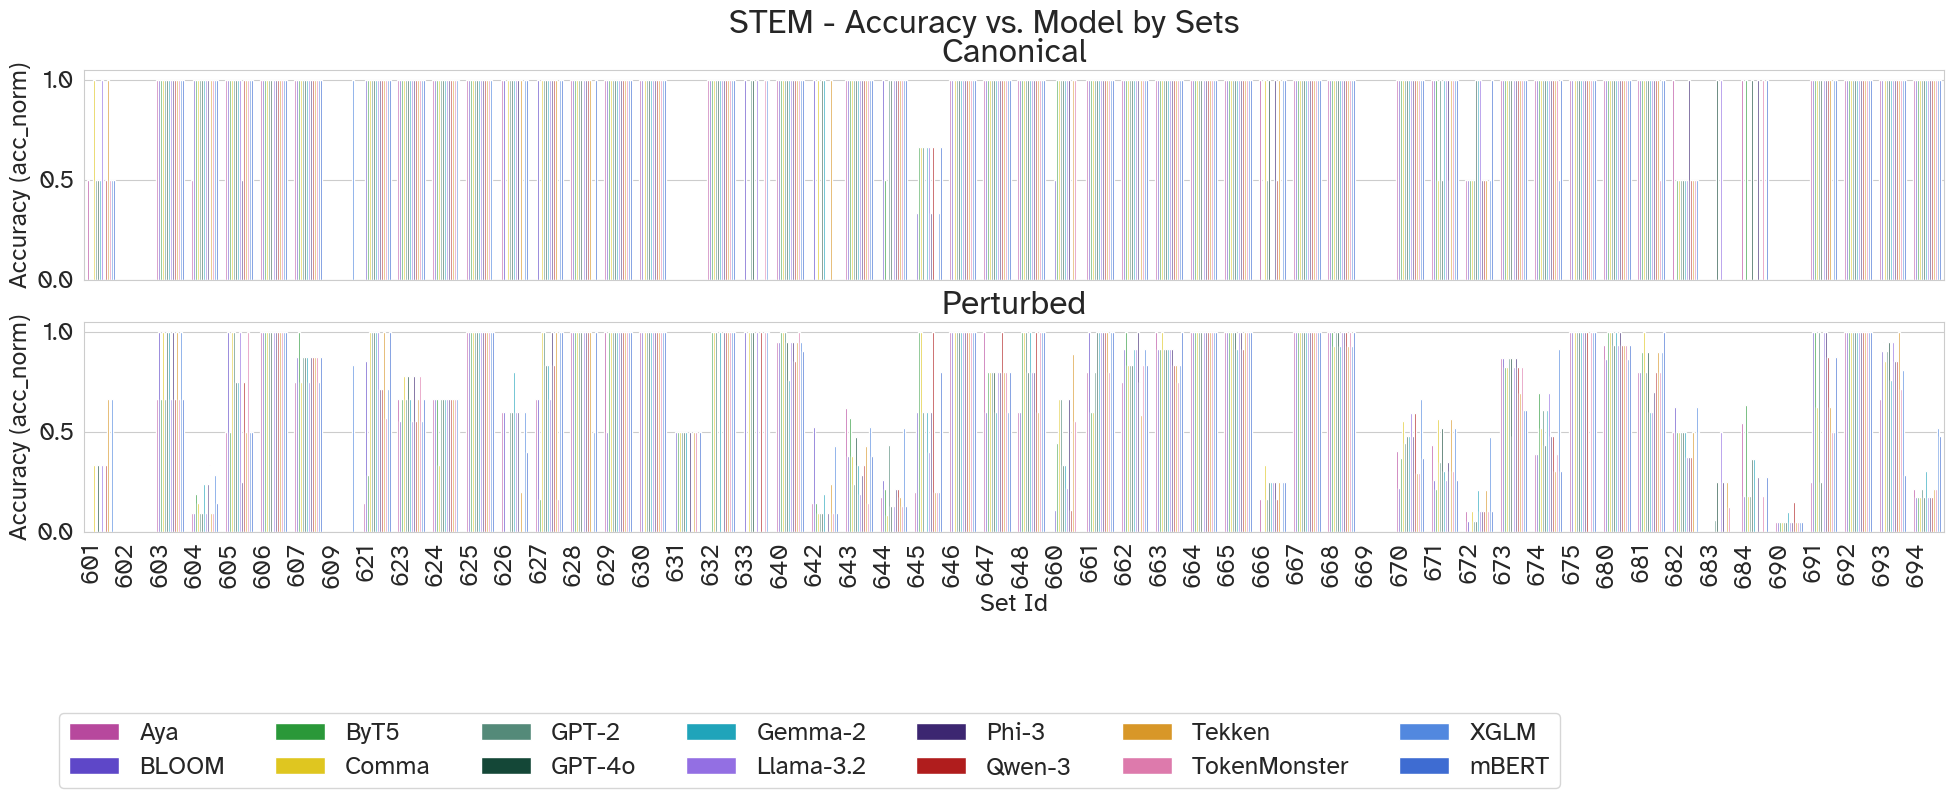

In [711]:
accuracies_by_model = all_samples.copy()
accuracies_by_model = all_samples.pivot_table(
    index=["set_id", "model_name", "is_canonical"], values=METRIC, aggfunc="mean"
).reset_index()
fig, axs = plt.subplots(2, 1, figsize=(24, 6), sharex=True)
axs = axs.flat
sns.barplot(
    accuracies_by_model[accuracies_by_model["is_canonical"]],
    x="set_id",
    y=METRIC,
    hue="model_name",
    palette=MODEL_TO_COLOR,
    ax=axs[0],
    legend=False,
)
axs[0].set_title("Canonical")
axs[1].set_title("Perturbed")

sns.barplot(
    accuracies_by_model[~accuracies_by_model["is_canonical"]],
    x="set_id",
    y=METRIC,
    hue="model_name",
    palette=MODEL_TO_COLOR,
    ax=axs[1],
    legend=True,
)
axs[1].legend(bbox_to_anchor=(0.8, -0.8, 0, 0), ncol=7)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Set Id")
axs[0].set_ylabel(f"Accuracy ({METRIC})")
axs[1].set_ylabel(f"Accuracy ({METRIC})")
fig.suptitle(f"{title_pattern}Accuracy vs. Model by Sets")
plt.savefig(OUTPUT_DIR/f"by_samples_canonical_vs_perturbed.pdf", pad_inches=0, bbox_inches="tight")

plt.show()

                                  acc_norm
model_name task_pretty_name               
Aya        ASCII                  0.588235
           Canonical              0.782609
           Character deletion     0.693878
           Combining Diacritics   0.407407
           Date formats           0.777778
...                                    ...
mBERT      Superscript/subscript  0.178571
           Typographical errors   0.769231
           Unicode formatting     0.678571
           Unusual formatting     0.631579
           Upside Down/Rotated    0.214286

[280 rows x 1 columns]


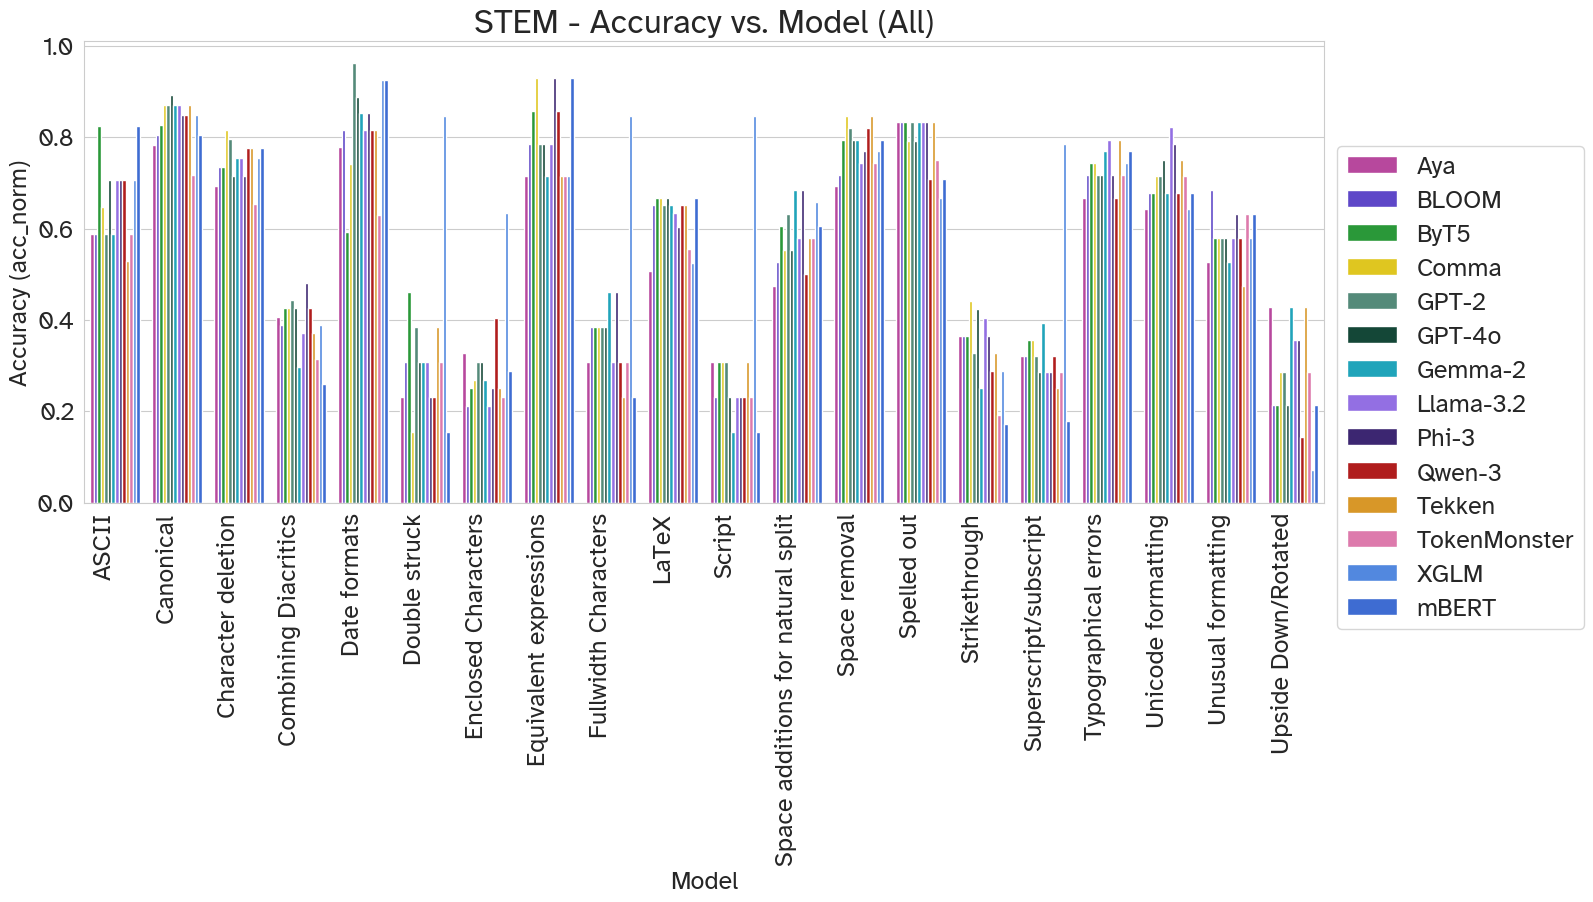

In [712]:
from xarch_tokenizers.logging.plot_utils import MODEL_TO_COLOR

accuracies_by_model = samples.pivot_table(
    index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="mean"
)
fig, axs = plt.subplots(1, 1, figsize=(16, 6))
sns.barplot(
    accuracies_by_model,
    x="task_pretty_name",
    y=METRIC,
    hue="model_name",
    # palette="viridis",
    palette=MODEL_TO_COLOR,
)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy ({METRIC})")
plt.title(f"{title_pattern}Accuracy vs. Model {suffix}")
plt.legend(bbox_to_anchor=(1, 0.8))
plt.savefig(OUTPUT_DIR/f"combined_{METRIC}.pdf", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

Plotting Canonical into position 1
1 False False
Plotting Typographical errors into position 2
2 False False
Plotting Space additions for natural split into position 3
3 False False
Plotting Space removal into position 4
4 False False
Plotting Character deletion into position 5
5 False False
Plotting Superscript/subscript into position 6
6 False False
Plotting Fullwidth Characters into position 7
7 False False
Plotting Upside Down/Rotated into position 8
8 False True


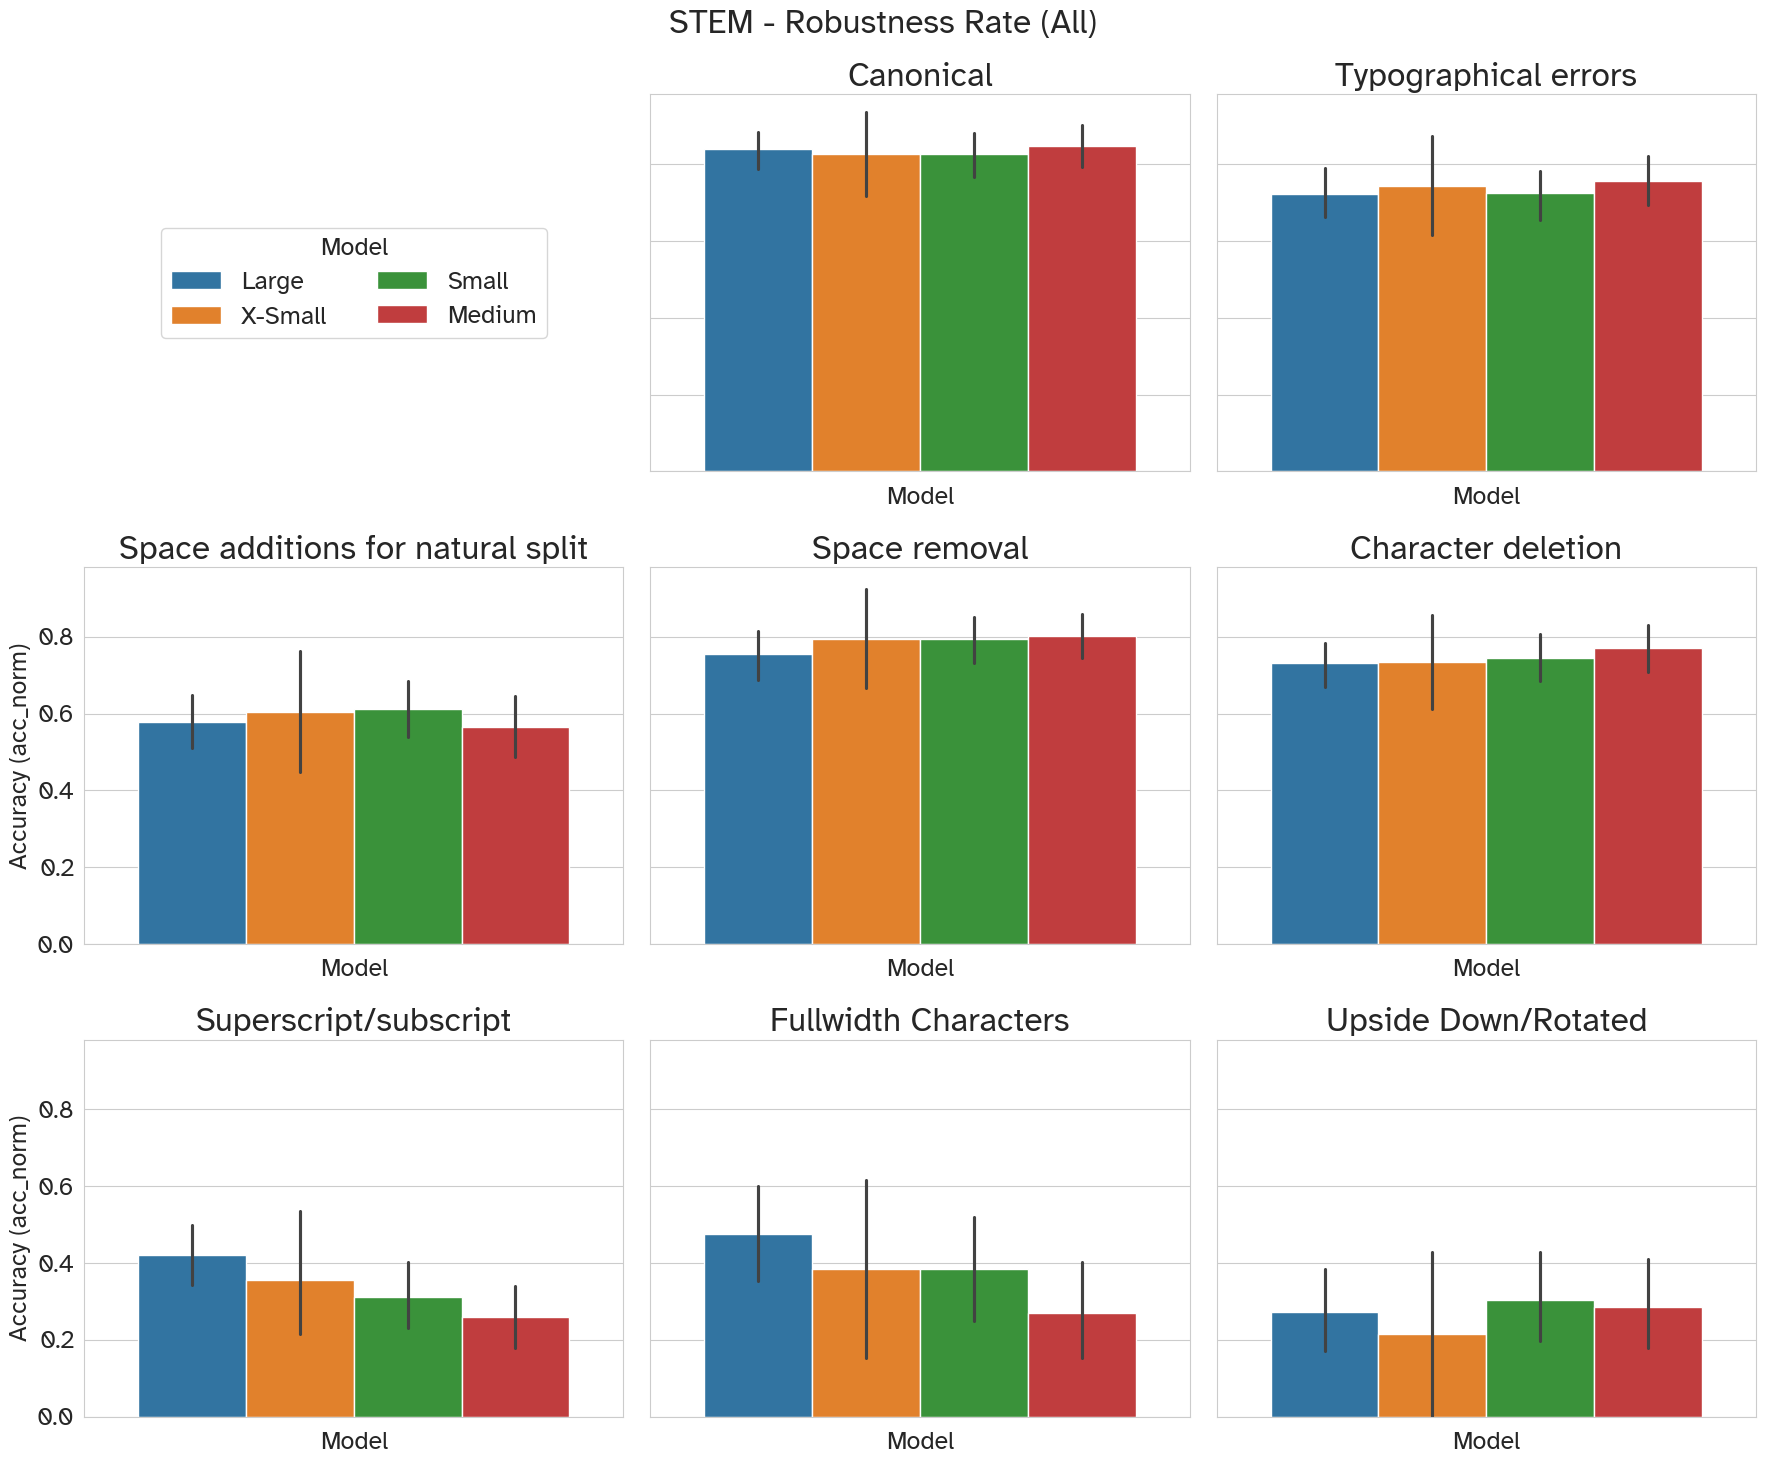

Plotting Combining Diacritics into position 0
9 False False
Plotting Strikethrough into position 1
10 False False
Plotting Script into position 2
11 False False
Plotting Double struck into position 3
12 False False
Plotting Enclosed Characters into position 4
13 False False
Plotting Spelled out into position 5
14 False False
Plotting Unusual formatting into position 6
15 False False
Plotting Equivalent expressions into position 7
16 False False
Plotting ASCII into position 8
17 False True


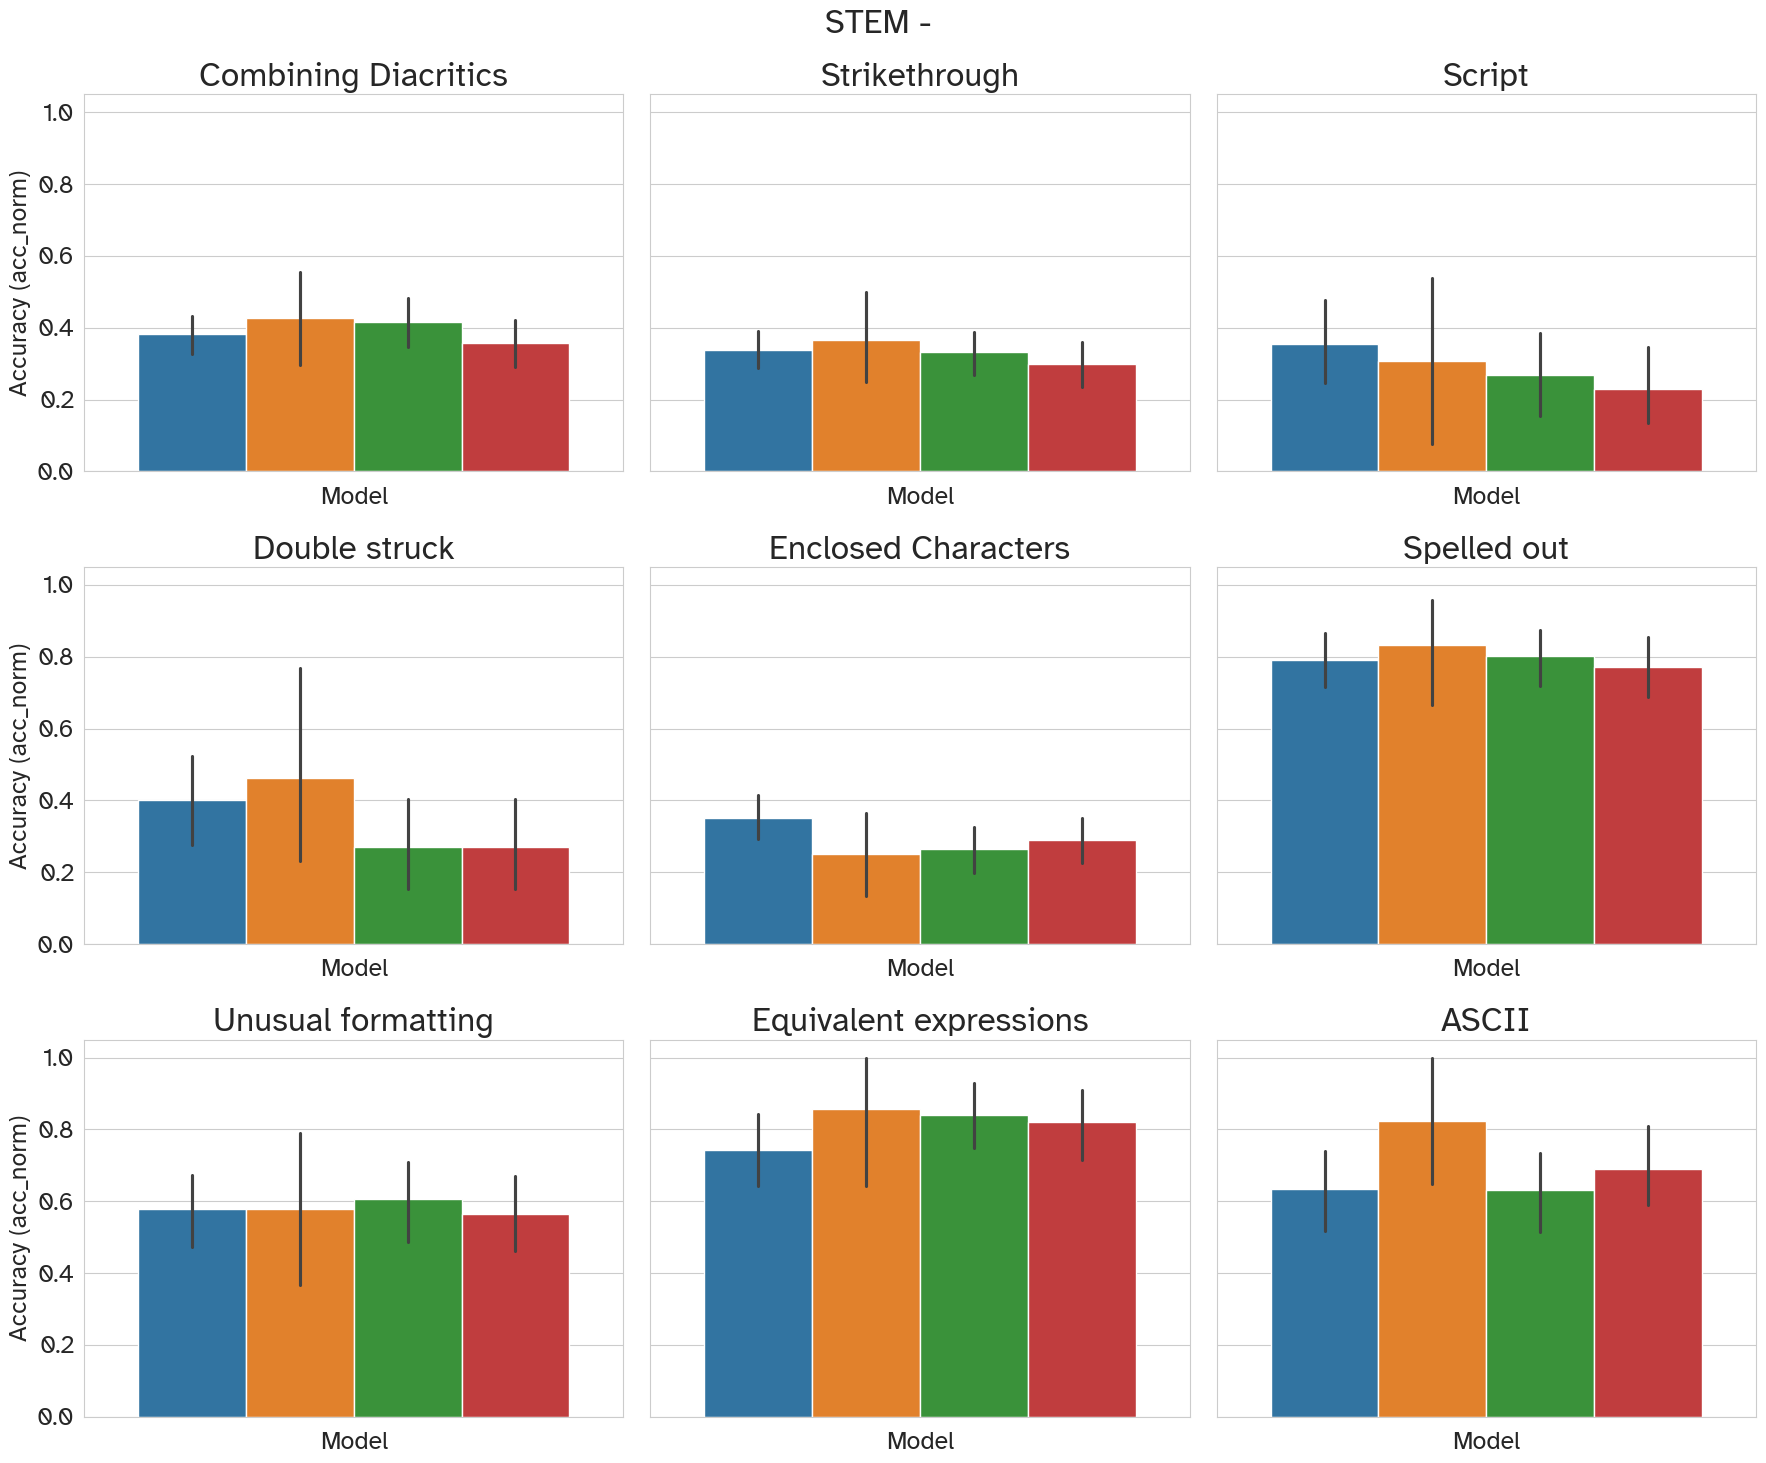

Plotting Unicode formatting into position 0
18 False False
Plotting LaTeX into position 1
19 False False
Plotting Date formats into position 2
20 False False


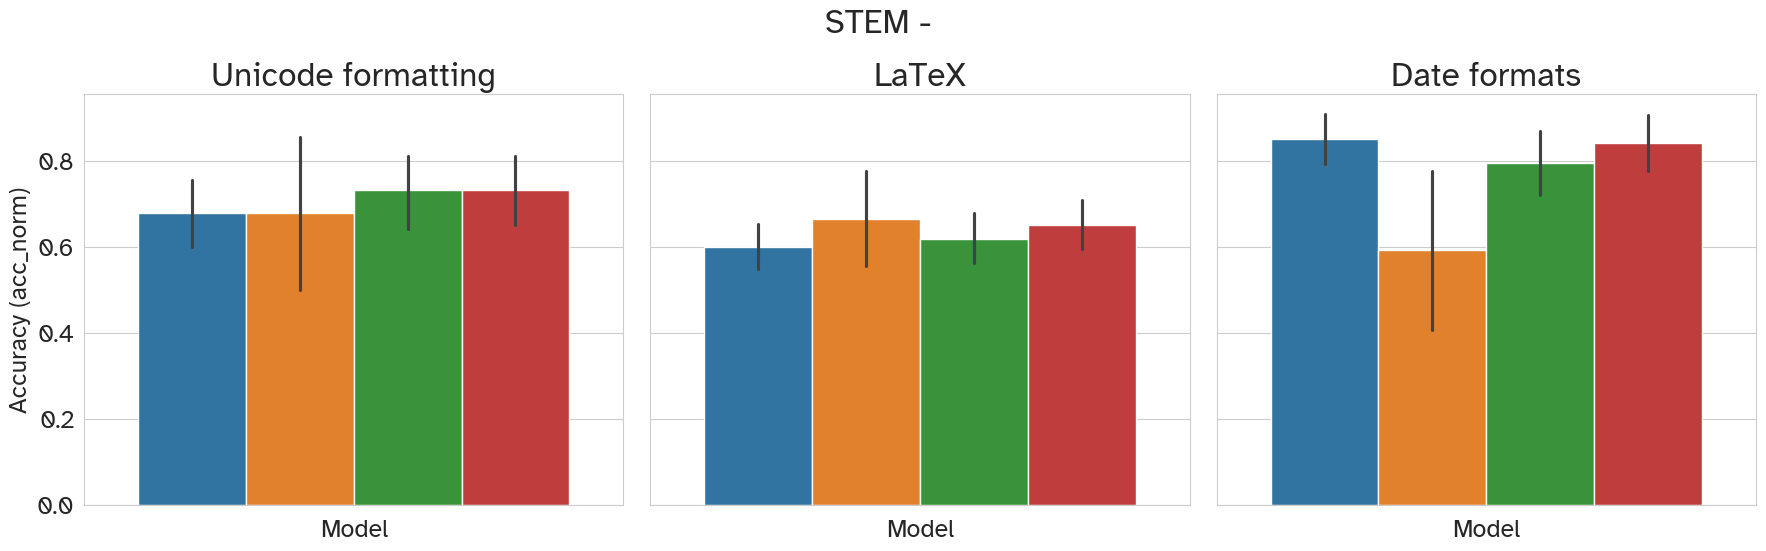

                                  acc_norm
model_name task_pretty_name               
Aya        ASCII                  0.588235
           Canonical              0.782609
           Character deletion     0.693878
           Combining Diacritics   0.407407
           Date formats           0.777778
...                                    ...
mBERT      Superscript/subscript  0.178571
           Typographical errors   0.769231
           Unicode formatting     0.678571
           Unusual formatting     0.631579
           Upside Down/Rotated    0.214286

[280 rows x 1 columns]


In [713]:
nrows, ncols = 3, 3
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern}Robustness Rate {suffix}"
)
fig_cnt = 0
PLOT_AXIS = "model_name"
PLOT_AXIS = "vocab_bucket"
palette = MODEL_TO_COLOR if PLOT_AXIS == "model_name" else None

samples = samples.sort_values(["model_name", "set_id", "variation_id"])
tasks = samples["task_pretty_name"].unique()
# tasks = tasks[1:]
for i, task in enumerate(tasks, 1):
    print(f"Plotting {task} into position {i % len(axs)}")
    filter_ = samples["task_pretty_name"] == task
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue=PLOT_AXIS, y=METRIC,ax=ax, legend=i == 1, palette=palette
    )
    ax.set_xlabel("Model")
    ax.set_ylabel(f"Accuracy ({METRIC})")
    title = task
    ax.set_title(title)
    # Check if we need to show the current figure
    is_last_task = i == len(tasks) + 1
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    if i == 1:
        # Add legend to the first subplot of current figure
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Model", loc="center", ncol=2)
        axs[1].legend().set_visible(False)
    print(i, is_last_task, is_end_of_6)
    if is_last_task or is_end_of_6:
        # Hide any unused subplots in the current figure
        if is_last_task:
            print(f"Last task: {i}, {task}")
            num_plots_in_current_fig = (i % ncols * nrows) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)
            break

        # Show the current figure
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/f"by_task_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
        plt.show()
        fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=title_pattern)
        fig_cnt += 1
# Hide any unused subplots if there are fewer than 6 tasks
for j in range((len(tasks) + 1) % (ncols * nrows), ncols * nrows):
    axs[j].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(OUTPUT_DIR/f"by_task_by_{PLOT_AXIS.lower()}_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
plt.show()

print(accuracies_by_model)

### By Model

In [714]:
OUTPUT_DIR.absolute()

PosixPath('/Users/gsaltintas/code/phd/tokenizers/notebooks/output/prelim-results-v3/stem/all')

Plotting Aya into position 1
Plotting BLOOM into position 2
Plotting ByT5 into position 3
Plotting Comma into position 4


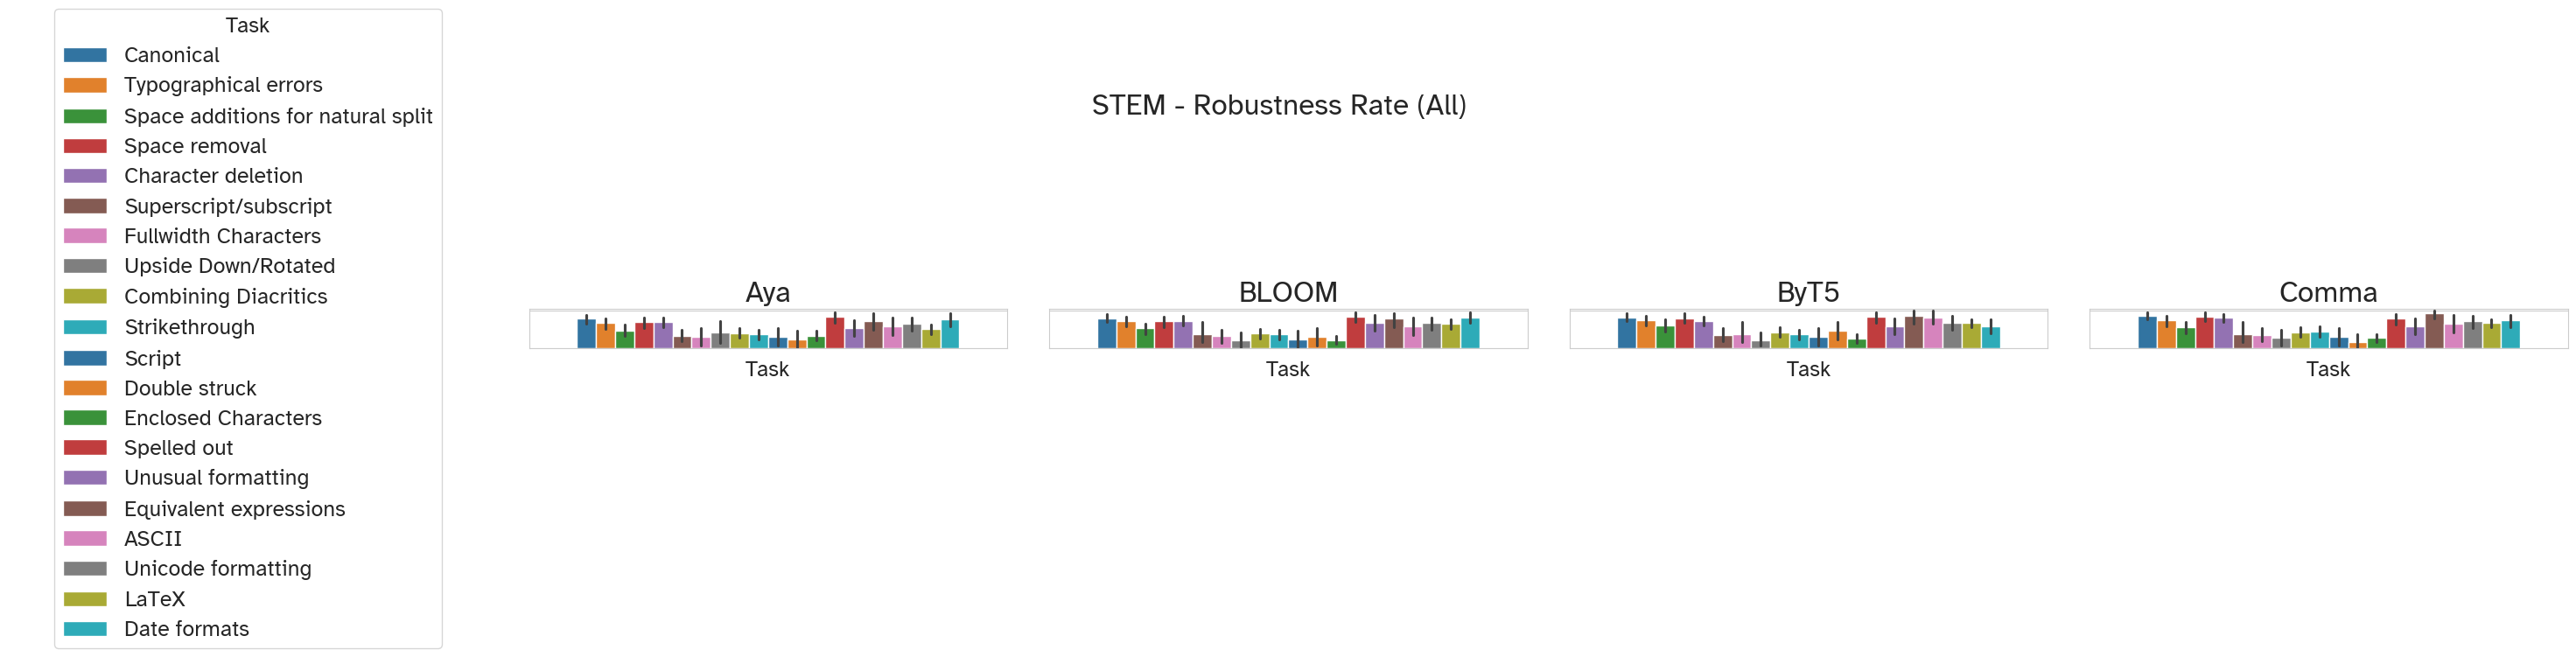

Plotting GPT-2 into position 0
Plotting GPT-4o into position 1
Plotting Gemma-2 into position 2
Plotting Llama-3.2 into position 3
Plotting Phi-3 into position 4


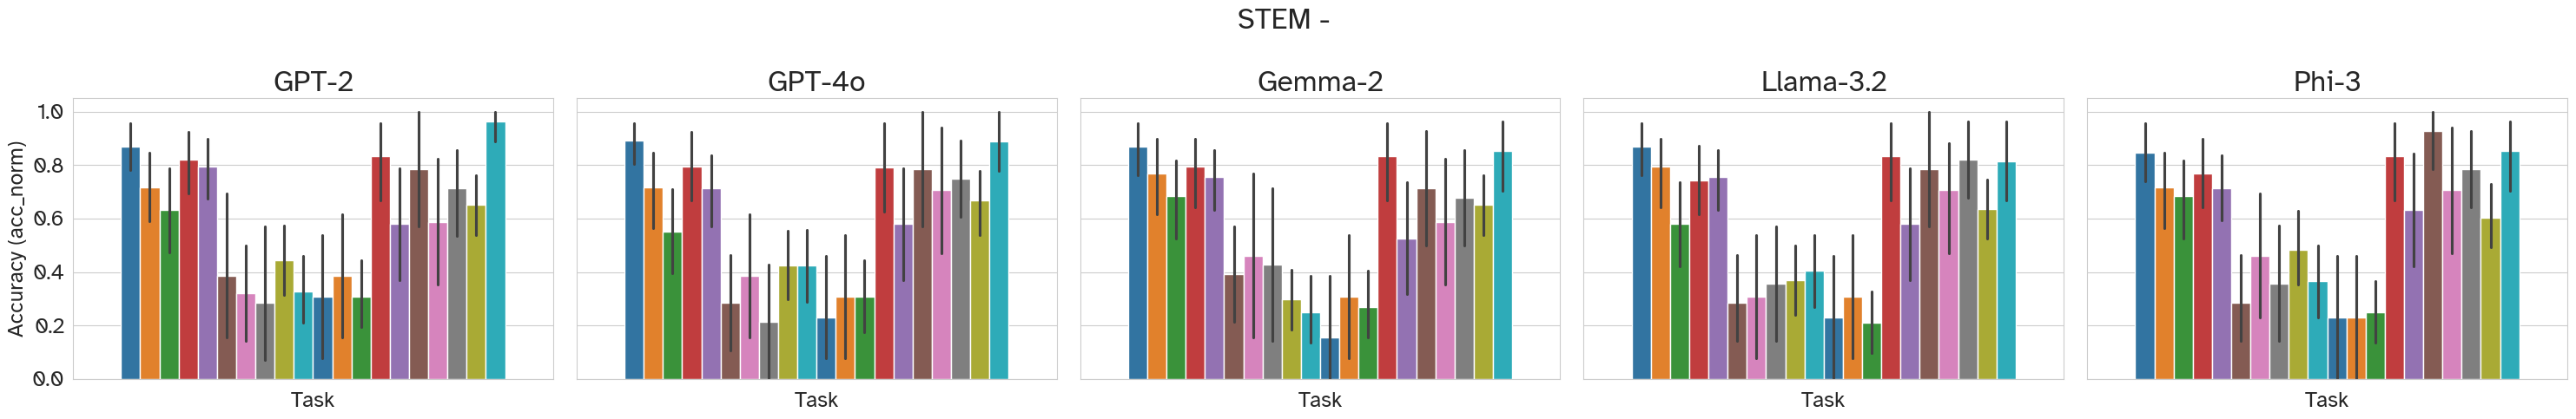

Plotting Qwen-3 into position 0
Plotting Tekken into position 1
Plotting TokenMonster into position 2
Plotting XGLM into position 3
Plotting mBERT into position 4


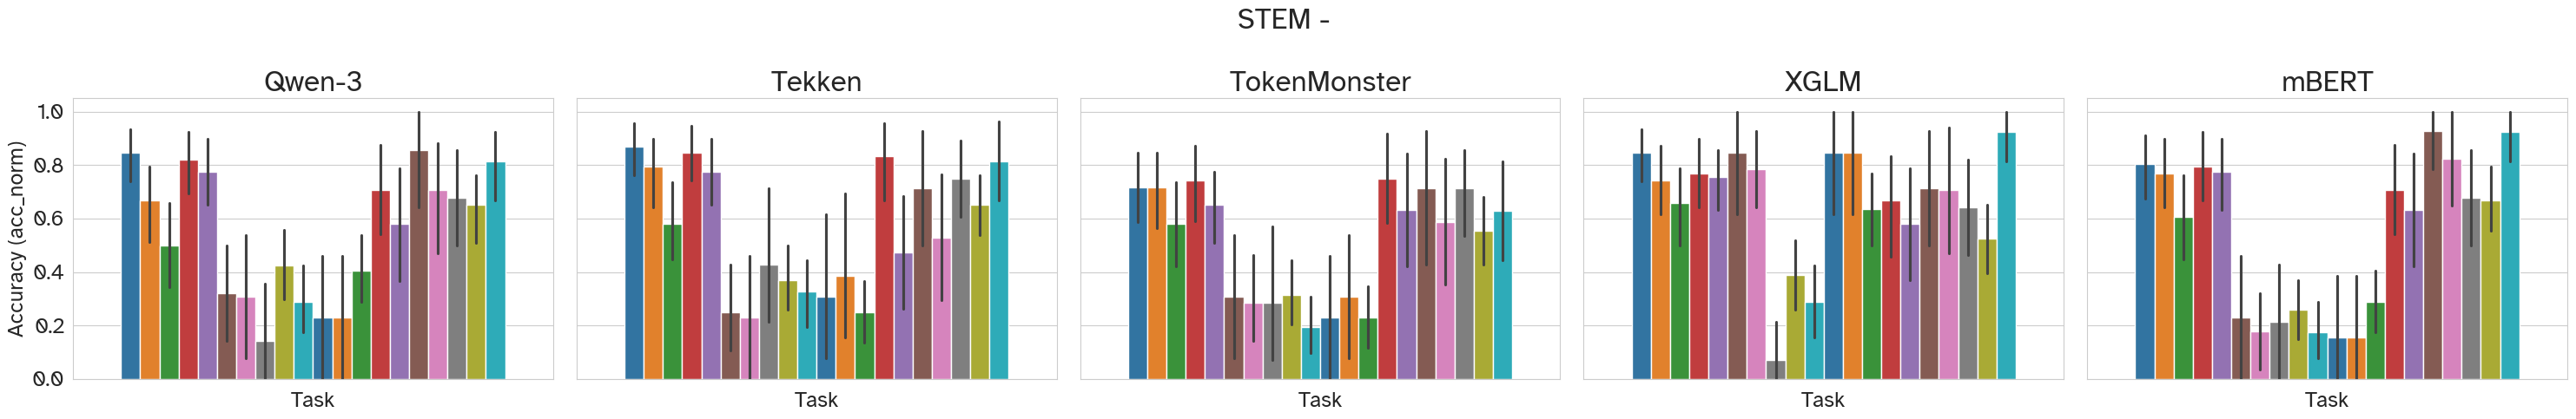

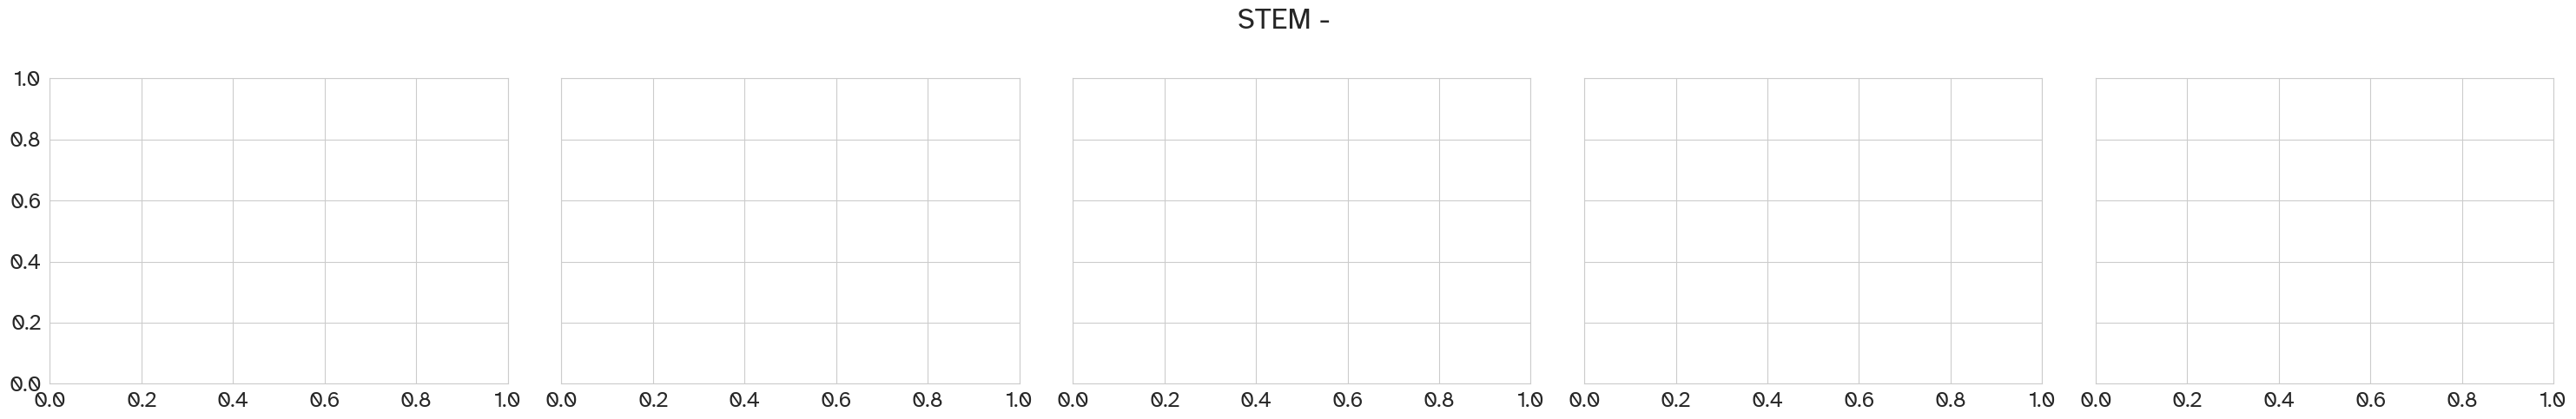

                                  acc_norm
model_name task_pretty_name               
Aya        ASCII                  0.588235
           Canonical              0.782609
           Character deletion     0.693878
           Combining Diacritics   0.407407
           Date formats           0.777778
...                                    ...
mBERT      Superscript/subscript  0.178571
           Typographical errors   0.769231
           Unicode formatting     0.678571
           Unusual formatting     0.631579
           Upside Down/Rotated    0.214286

[280 rows x 1 columns]


In [715]:
nrows, ncols = 1, 5
PLOT_AXIS="model_name"
# PLOT_AXIS="vocab_bucket"
HUE="task_pretty_name"
# HUE="task"
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern}Robustness Rate {suffix}"
)
fig_cnt = 0
models = samples[PLOT_AXIS].unique()
sorted(models)
for i, model in enumerate(models, 1):
    print(f"Plotting {model} into position {i % len(axs)}")
    filter_ = samples[PLOT_AXIS] == model
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue=HUE, y=METRIC, palette="tab10", ax=ax, legend=i == 1
    )
    ax.set_xlabel("Task")
    ax.set_ylabel(f"Accuracy ({METRIC})")
    title=model
    ax.set_title(title)
    # Check if we need to show the current figure
    is_last_task = i == len(models) + 1
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    if i == 1:
        # Add legend to the first subplot of current figure
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Task", loc="center", ncol=1)
        axs[1].legend().set_visible(False)
    if is_last_task or is_end_of_6:
        # Hide any unused subplots in the current figure
        if is_last_task:
            num_plots_in_current_fig = (i % ncols * nrows) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)

        # Show the current figure
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/f"by_model_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
        plt.show()
        fig_cnt += 1
        fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=title_pattern)
# Hide any unused subplots if there are fewer than 6 tasks
# for j in range((len(models)+1) % (ncols * nrows), ncols * nrows):
#     axs[j].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(OUTPUT_DIR/f"by_model_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")

plt.show()

print(accuracies_by_model)

### Examples per perturbation

In [716]:
pv = all_samples[all_samples["model_name"] == "Aya"].pivot_table(index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="count")
pv.to_csv(OUTPUT_DIR/"sample_counts.csv")
pv


acc_norm
model_name task_pretty_name                           
Aya        ASCII                                    17
           Canonical                                46
           Character deletion                       49
           Combining Diacritics                     54
           Date formats                             27
           Double struck                            13
           Enclosed Characters                      52
           Equivalent expressions                   14
           Fullwidth Characters                     13
           LaTeX                                    63
           Script                                   13
           Space additions for natural split        38
           Space removal                            39
           Spelled out                              24
           Strikethrough                            52
           Superscript/subscript                    28
           Typographical errors                     39
           Unicode formatting                       28
           Unusual formatting                       19
           Upside Down/Rotated                      14

### Against tokenizer props

#### Token count

In [717]:
models = samples["model_name"].unique()

sns.histplot(samples, x="model_name", y="token_counts")

ValueError: Could not interpret value `token_counts` for `y`. An entry with this name does not appear in `data`.

In [ ]:
samples.columns

Index(['doc_id', 'target', 'resps', 'metrics', 'acc', 'acc_norm', 'model_name',
       'task', 'question', 'choices', 'answer', 'answer_label', 'split',
       'subcategories', 'categories', 'lang', 'second_lang', 'notes', 'id',
       'set_id', 'variation_id',
       'vanilla_cos_sim_to_canonical.CohereLabs/aya-expanse-8b',
       'vanilla_cos_sim_to_canonical.Qwen/Qwen3-8B',
       'vanilla_cos_sim_to_canonical.bigscience/bloom',
       'vanilla_cos_sim_to_canonical.common-pile/comma-v0.1-1t',
       'vanilla_cos_sim_to_canonical.facebook/xglm-564M',
       'vanilla_cos_sim_to_canonical.google-bert/bert-base-multilingual-cased',
       'vanilla_cos_sim_to_canonical.google/byt5-small',
       'vanilla_cos_sim_to_canonical.google/gemma-2-2b',
       'vanilla_cos_sim_to_canonical.gpt2',
       'vanilla_cos_sim_to_canonical.meta-llama/Llama-3.2-1B',
       'vanilla_cos_sim_to_canonical.microsoft/Phi-3-mini-4k-instruct',
       'vanilla_cos_sim_to_canonical.mistralai/tekken',
       'vani

In [ ]:
toks = samples["tokenizer_name"].unique()
tok_count_cols = [f"token_counts.{tok_name}" for tok_name in toks]
tok_counts = samples[tok_count_cols]
tok_counts.columns=toks
tok_counts 


,google/byt5-small,bigscience/bloom,common-pile/comma-v0.1-1t,google-bert/bert-base-multilingual-cased,Qwen/Qwen3-8B,gpt2,CohereLabs/aya-expanse-8b
0,80,35,41,25,23,42,22
1,26,11,12,9,10,15,6
2,20,8,9,7,8,12,5
3,49,22,26,19,25,22,23
4,40,14,23,13,22,20,20
...,...,...,...,...,...,...,...
4076,30,12,13,7,10,13,6
4077,29,10,10,7,9,12,5
4078,18,8,10,6,6,11,5
4079,27,10,13,9,10,14,7


In [ ]:
samples["tokenizer_name"]

0               google/byt5-small
1               google/byt5-small
2               google/byt5-small
3               google/byt5-small
4               google/byt5-small
                  ...            
4076    CohereLabs/aya-expanse-8b
4077    CohereLabs/aya-expanse-8b
4078    CohereLabs/aya-expanse-8b
4079    CohereLabs/aya-expanse-8b
4080    CohereLabs/aya-expanse-8b
Name: tokenizer_name, Length: 4081, dtype: object

In [ ]:
for i, row in samples.iterrows():
    samples.iloc[i, "token_count"]=

,doc_id,target,resps,metrics,acc,acc_norm,model_name,tokenizer_name,task,question,...,token_counts.google/gemma-2-2b,token_counts.gpt2,token_counts.meta-llama/Llama-3.2-1B,token_counts.microsoft/Phi-3-mini-4k-instruct,token_counts.mistralai/tekken,token_counts.tiktoken/gpt-4o,token_counts.tokenmonster/englishcode-32000-consistent-v1,answer_choice,task_pretty_name,is_canonical
0,0,0,"[[[-7.9375, False]], [[-15.0625, False]], [[-1...","[acc, acc_norm]",1,1,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Dr Gülçiçek Bölükbaşı bir doktordur. Gülçiçek ...,...,23,42,28,37,26,26,54,doktorluktur,Derivations,False
1,1,2,"[[[-11.875, False]], [[-12.1875, False]], [[-1...","[acc, acc_norm]",1,0,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Gökyüzünün renklenişi,...,7,15,8,12,9,8,17,mavidir,Derivations,False
2,2,3,"[[[-7.21875, False]], [[-11.0625, False]], [[-...","[acc, acc_norm]",0,0,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Gökyüzünün rengi,...,5,12,8,9,8,6,14,mavimsidir,Derivations,False
3,3,0,"[[[-8.5625, False]], [[-16.25, False]], [[-18....","[acc, acc_norm]",1,1,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,"Bu ev 5,850,000 Lira fiyatlı. Bu evin maaliyeti",...,22,22,20,28,25,20,24,"5,850,000 TL'dir",Derivations,False
4,4,3,"[[[-13.8125, False]], [[-13.9375, False]], [[-...","[acc, acc_norm]",0,0,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Bugün 17/08/1998'dir. Bugünkü tarihi,...,20,20,16,24,21,16,25,17/8/1998'dir,Derivations,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4076,6,0,"[[[-16.75, False]], [[-12.625, False]], [[-12....","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Bir dakikadaki saniye sayısı,...,9,13,8,13,9,9,16,altmıştır,Spelled out,False
4077,7,2,"[[[-9.0625, False]], [[-8.125, False]], [[-8.5...","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Bir altıgenin kenar sayısı,...,8,12,7,12,9,9,16,altıdır,Spelled out,False
4078,8,2,"[[[-11.6875, False]], [[-14.4375, False]], [[-...","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Yüzün yüzde onu,...,5,11,5,10,6,5,11,ondur,Spelled out,False
4079,9,0,"[[[-11.875, False]], [[-15.375, False]], [[-16...","[acc, acc_norm]",1,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Seksenin yüzde yirmi beşi,...,9,14,10,14,11,9,16,yirmidir,Spelled out,False
